## Covered Call Sim

In [1]:
from quant_slc_hedging.data_model import LoanModelInputs, SalaryModelInputs, InvestmentModelInputs, SalaryGrowthType, salary_growth_amounts
from quant_slc_hedging.salary import SalaryModel
from quant_slc_hedging.loan import LoanModel, LoanModelResult
from quant_slc_hedging.strategies.base_strategy import Strategy
from quant_slc_hedging.strategies.min_repayment import MinRepaymentStrategy
from quant_slc_hedging.strategies.fixed_pct_repayment import FixedPctRepaymentStrategy
from quant_slc_hedging.strategies.index_fund import IndexFundStrategy
from quant_slc_hedging.strategies.covered_call import CoveredCallStrategy
from quant_slc_hedging.simulation import SimulationHandler
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
from typing import List, Union
from dataclasses import dataclass
import matplotlib.pyplot as plt

In [7]:
n_paths = 10_000
years_remaining = 30
observations = years_remaining * 12
seed = 1234
starting_salary = 35_000
initial_loan = 45_000
initial_investment_balance = 1
salary_growth = SalaryGrowthType(growth_type="Medium")
salary_config=SalaryModelInputs(
    starting_salary=starting_salary,
    salary_growth_dist=salary_growth
    )
loan_config = LoanModelInputs(
    initial_loan_balance=initial_loan,
    remaining_loan_term_months=12*years_remaining
)
investment_config = InvestmentModelInputs(
    initial_investment_balance=initial_investment_balance,
    annual_expected_return=0.07,
    annual_vol=0.25,
    payoff_loan_with_investments=True
)
salary_rng = np.random.default_rng(seed)
investment_rng = np.random.default_rng(seed + 1) 
strategy = CoveredCallStrategy(investment_config=investment_config, investment_pct=0.05, repayment_pct=0.0, repayment_threshold=loan_config.repayment_threshold, target_moneyness=1.2, rng_gen=investment_rng, n_paths=n_paths, n_obs=observations)
sim = SimulationHandler(salary_config=salary_config, loan_config=loan_config, investment_config=investment_config, strategy=strategy, n_paths=n_paths, observations=observations, salary_rng=salary_rng)
res = sim.run_simulation()
print("done")

Sim finished
done


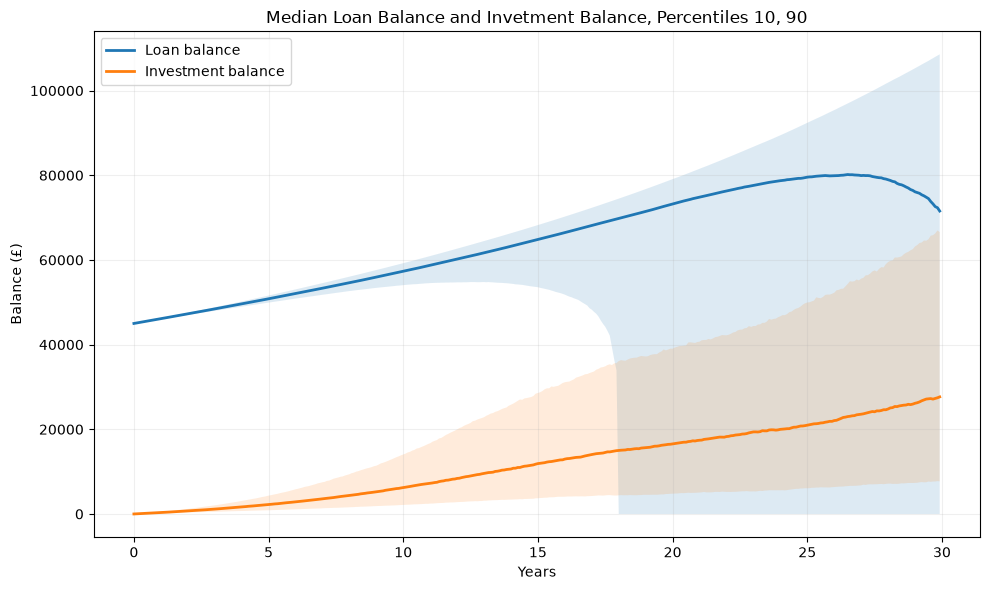

In [8]:
# Time axis in years
time = np.arange(observations) / 12

# Extract simulation results
loan = res.loan_result.loan_balance
investment = res.investment_balance

# Median and percentile bands
loan_median = np.median(loan, axis=0)
loan_p10 = np.percentile(loan, 10, axis=0)
loan_p90 = np.percentile(loan, 90, axis=0)

investment_median = np.median(investment, axis=0)
investment_p10 = np.percentile(investment, 10, axis=0)
investment_p90 = np.percentile(investment, 90, axis=0)

fig, ax = plt.subplots(figsize=(10, 6))

# Loan balance
ax.plot(
    time,
    loan_median,
    label="Loan balance",
    linewidth=2,
)

ax.fill_between(
    time,
    loan_p10,
    loan_p90,
    alpha=0.15,
)

# Investment balance
ax.plot(
    time,
    investment_median,
    label="Investment balance",
    linewidth=2,
)

ax.fill_between(
    time,
    investment_p10,
    investment_p90,
    alpha=0.15,
)

ax.set_xlabel("Years")
ax.set_ylabel("Balance (£)")
ax.set_title("Median Loan Balance and Invetment Balance, Percentiles 10, 90")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

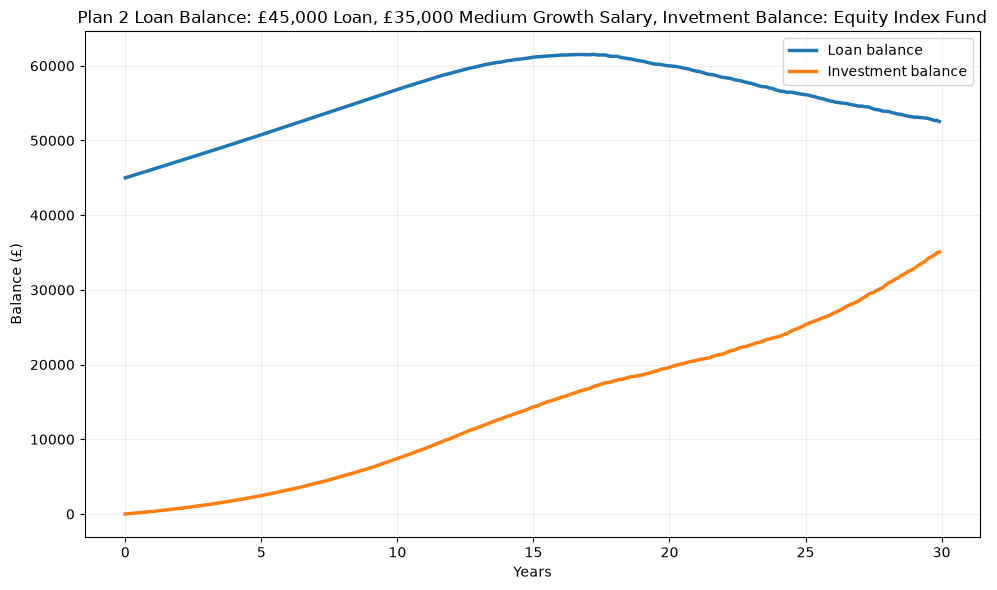

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
loan_mean = np.mean(loan, axis=0)
investment_mean = np.mean(investment, axis=0)

ax.plot(
    time,
    loan_mean,
    label="Loan balance",
    linewidth=2.5,
)

ax.plot(
    time,
    investment_mean,
    label="Investment balance",
    linewidth=2.5,
)

# ax.axhline(0, linewidth=1)

ax.set_xlabel("Years")
ax.set_ylabel("Balance (£)")
ax.set_title("Plan 2 Loan Balance: £45,000 Loan, £35,000 Medium Growth Salary, Invetment Balance: Equity Index Fund")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()